### Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd 
import os 
import yaml
from pathlib import Path
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from typing import Any, Mapping


In [3]:
from qbt.strategies.strategy_registry import create_strategy, available_strategies 
from qbt.data.dataloader import DataAdapter, DefaultDataAdapter

from qbt.core.types import ModelInputs, RunSpec

In [4]:
style_path = os.path.join(os.getcwd(), 'styler.mplstyle')
plt.style.use(style_path)

In [5]:
def load_data(experiment: str = "macro_variables"):
    base_path = os.path.join(
        os.getcwd(),
        "..",
        "artifacts",
        "backtesting_results",
        f"experiment={experiment}",
    )

    # -------------------------
    # 1) Load run summary
    # -------------------------
    runs_path = os.path.join(base_path, "runs_summary.parquet")
    runs_df = pd.read_parquet(runs_path)

    # -------------------------
    # 2) Load all timeseries
    # -------------------------
    ts_pattern = os.path.join(
        base_path,
        "timeseries",
        "run_id=*",
        "timeseries.parquet",
    )

    ts_files = glob.glob(ts_pattern)

    ts_list = []
    for f in ts_files:
        print(f)
        df = pd.read_parquet(f)

        # if "date" in df.columns:
        #     df["date"] = pd.to_datetime(df["date"], utc=True)
        #     df = df.set_index("date")

        ts_list.append(df)

    if ts_list:
        timeseries_df = pd.concat(ts_list, axis=0)
    else:
        timeseries_df = pd.DataFrame()

    return runs_df, timeseries_df

In [6]:
runs_df, timeseries_df = load_data()

/home/jackyeung99/classes/proj_quant_trading/notebooks/../artifacts/backtesting_results/experiment=macro_variables/timeseries/run_id=20260317_204446_1ad47817_StateSignal_XLE/timeseries.parquet
/home/jackyeung99/classes/proj_quant_trading/notebooks/../artifacts/backtesting_results/experiment=macro_variables/timeseries/run_id=20260317_204451_56dc0602_StateSignal_XLE/timeseries.parquet
/home/jackyeung99/classes/proj_quant_trading/notebooks/../artifacts/backtesting_results/experiment=macro_variables/timeseries/run_id=20260316_173952_4ed00cca_StateSignal_XLE/timeseries.parquet
/home/jackyeung99/classes/proj_quant_trading/notebooks/../artifacts/backtesting_results/experiment=macro_variables/timeseries/run_id=20260316_173901_41576dc8_StateSignal_XLE/timeseries.parquet
/home/jackyeung99/classes/proj_quant_trading/notebooks/../artifacts/backtesting_results/experiment=macro_variables/timeseries/run_id=20260317_204405_eb8e703b_StateSignal_XLE/timeseries.parquet
/home/jackyeung99/classes/proj_quan

### XLE Companies

In [7]:

path = os.path.join(os.getcwd(), '..', 'data', 'external', 'holdings-xle-2-26-26.csv')
xle = pd.read_csv(path)


In [8]:
xle

,Name,Ticker,Identifier,SEDOL,Weight,Sector,Shares Held,Local Currency
0,EXXON MOBIL CORP,XOM,30231G102,2326618,23.811213,-,59780973.00,USD
1,CHEVRON CORP,CVX,166764100,2838555,17.308917,-,35050923.00,USD
2,CONOCOPHILLIPS,COP,20825C104,2685717,6.792925,-,22884112.00,USD
3,WILLIAMS COS INC,WMB,969457100,2967181,4.633501,-,23110361.00,USD
4,SLB LTD,SLB,806857108,2779201,4.462036,-,32317295.00,USD
5,EOG RESOURCES INC,EOG,26875P101,2318024,3.812521,-,11737764.00,USD
6,KINDER MORGAN INC,KMI,49456B101,B3NQ4P8,3.754470,-,42351682.00,USD
7,BAKER HUGHES CO,BKR,05722G100,BDHLTQ5,3.714883,-,21346431.00,USD
8,VALERO ENERGY CORP,VLO,91913Y100,2041364,3.605583,-,6598078.00,USD
9,PHILLIPS 66,PSX,718546104,B78C4Y8,3.563322,-,8716136.00,USD


### Candidate State Variables 

In [9]:
merged = pd.merge(timeseries_df, runs_df, on='run_id')

In [10]:
merged.columns

Index(['run_id', 'date', 'port_ret_gross', 'port_ret_net', 'equity_gross',
       'equity_net', 'turnover', 'cost', 'bh_ret', 'bh_equity',
       'excess_ret_net', 'excess_equity_net', 'weight_XLE',
       'asset_ret_gross_XLE', 'state_value', 'signal', 'tau_star', 'w_low',
       'w_high', 'strategy_name', 'universe', 'created_at_utc', 'data_path',
       'weight_lag', 'tag', 'params_json', 'params_state_var',
       'params_min_frac', 'params_w_min', 'params_w_max',
       'params_weight_allocation', 'params_gamma', 'metric_gross_n_obs',
       'metric_gross_mean_ann', 'metric_gross_vol_ann', 'metric_gross_sharpe',
       'metric_gross_cagr', 'metric_gross_max_dd',
       'metric_gross_ending_equity', 'metric_net_n_obs', 'metric_net_mean_ann',
       'metric_net_vol_ann', 'metric_net_sharpe', 'metric_net_cagr',
       'metric_net_max_dd', 'metric_net_ending_equity', 'metric_bh_n_obs',
       'metric_bh_mean_ann', 'metric_bh_vol_ann', 'metric_bh_sharpe',
       'metric_bh_cagr', 'metr

In [11]:
best = runs_df.sort_values(by=['metric_gross_sharpe'], ascending=False)['run_id'].iloc[0]
best

'20260317_204159_59c5bc85_StateSignal_XLE'

In [12]:
runs_df.sort_values(by=['metric_gross_sharpe'], ascending=False).iloc[0]

run_id                                       20260317_204159_59c5bc85_StateSignal_XLE
strategy_name                                                             StateSignal
universe                                                                          XLE
created_at_utc                                       2026-03-17T20:41:59.500303+00:00
data_path                              data/gold/freq=1D/tag=experiment/table.parquet
weight_lag                                                                          1
tag                                                                      rv_regime_5m
params_json                         {"gamma": 5.0, "min_frac": 0.05, "state_var": ...
params_state_var                                                             XLE_rvol
params_min_frac                                                                  0.05
params_w_min                                                                        0
params_w_max                                          

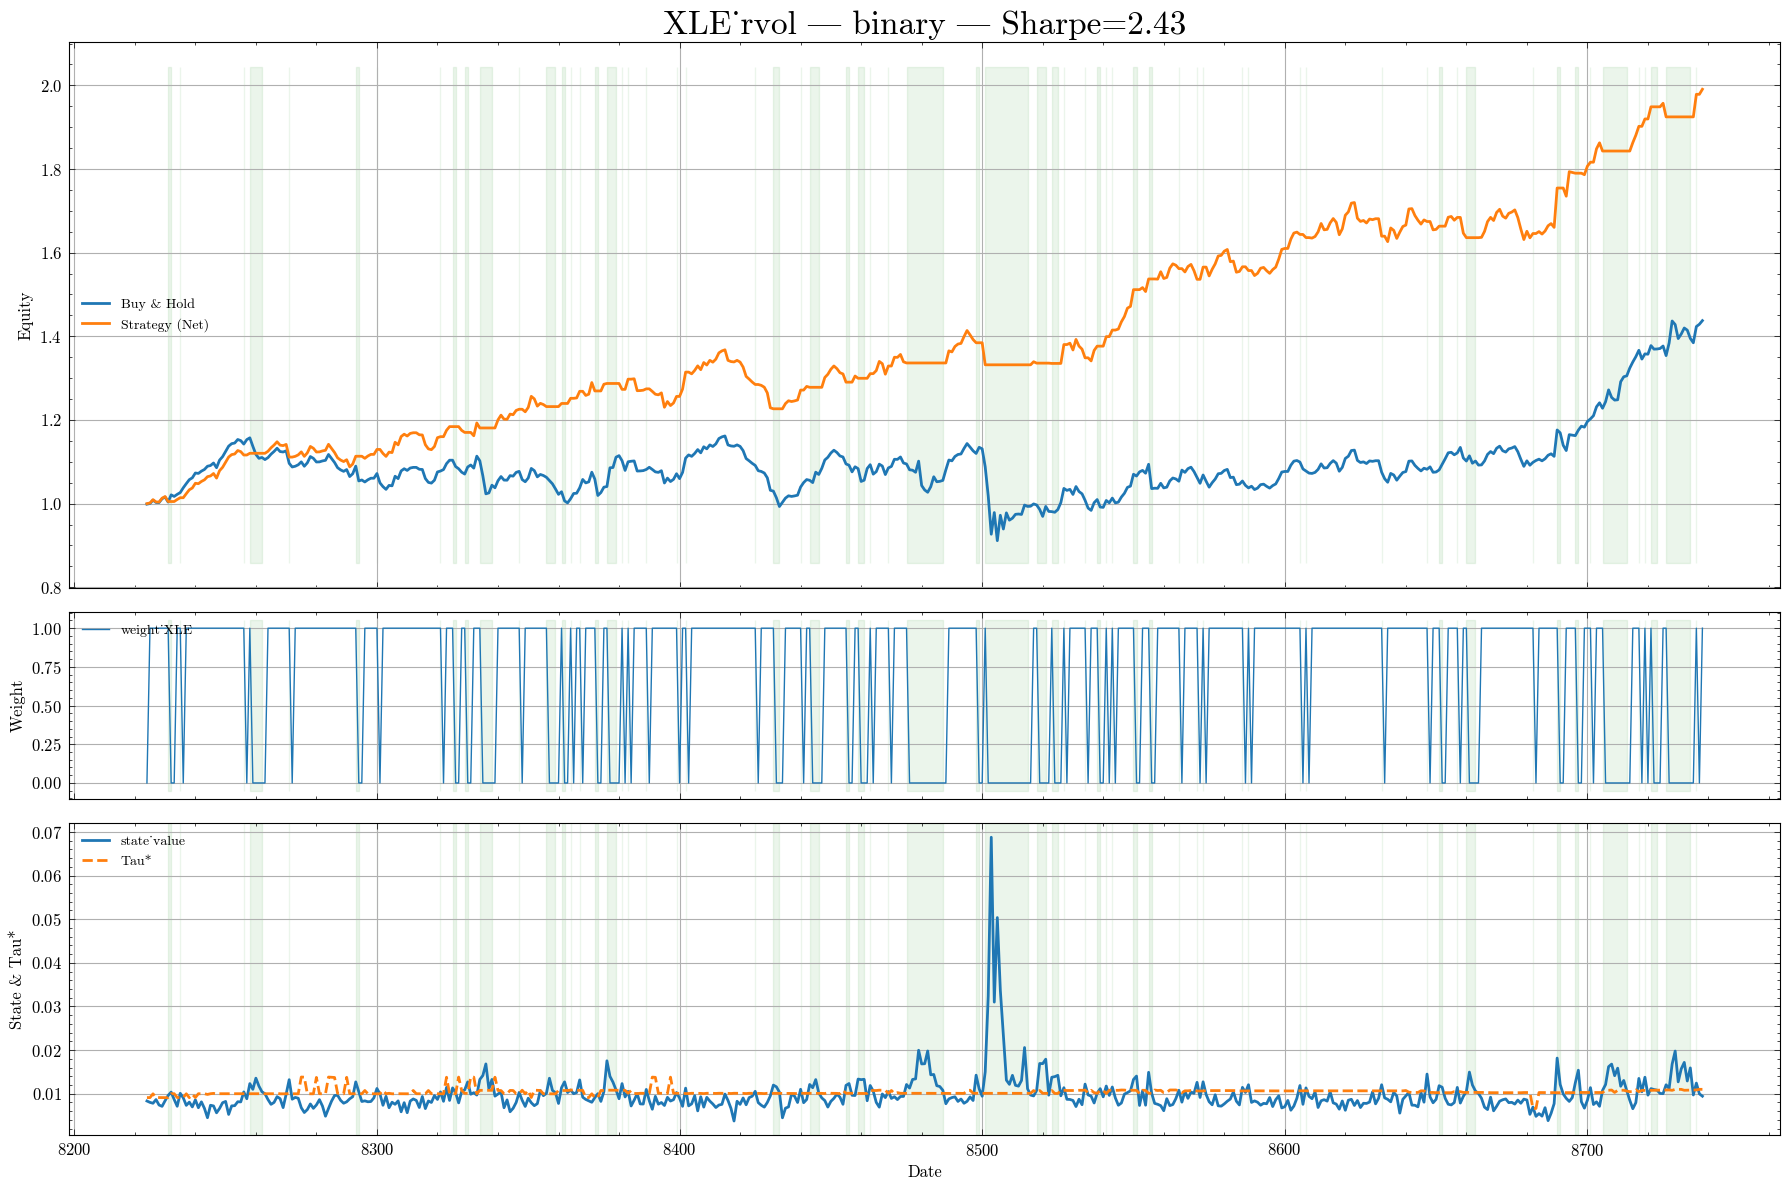

In [13]:

# merged has BOTH run_summary columns + timeseries columns
best_time = merged.loc[merged["run_id"] == best].copy().sort_index()


def _first_non_null(s: pd.Series, default=None):
    s2 = s.dropna()
    return s2.iloc[0] if not s2.empty else default

state_name = _first_non_null(best_time.get("params_state_var", pd.Series(dtype=object)), default="unknown_state")
weight_method = _first_non_null(best_time.get("params_weight_allocation", pd.Series(dtype=object)), default="unknown_weight")
sharpe = _first_non_null(best_time.get("metric_gross_sharpe", pd.Series(dtype=float)), default=np.nan)

weight_cols = ["weight_XLE"]

# state value series (prefer explicit stored series)
state_value_col = None
for cand in ("state_value", "S_used"):
    if cand in best_time.columns:
        state_value_col = cand
        break
if state_value_col is None and isinstance(state_name, str) and state_name in best_time.columns:
    state_value_col = state_name

title = f"{state_name} | {weight_method} | Sharpe={sharpe:.2f}"

# ---- regime mask (for shading all panels) ----
regime = None
if ("tau_star" in best_time.columns) and (state_value_col is not None):
    s2 = pd.to_numeric(best_time[state_value_col], errors="coerce").ffill()
    t2 = pd.to_numeric(best_time["tau_star"], errors="coerce").ffill()
    regime = (s2 > t2) & s2.notna() & t2.notna()

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(18, 12),
    sharex=True,
    gridspec_kw={"height_ratios": [3.5, 1.2, 2]},
)

def shade(ax):
    """Shade 'in-regime' periods on a given axis."""
    if regime is None or not regime.any():
        return
    y0, y1 = ax.get_ylim()
    ax.fill_between(
        best_time.index,
        y0,
        y1,
        where=regime.values,
        alpha=0.08,
        color="green",
        zorder=0,
    )

# ---------------------------
# 1) Equity
# ---------------------------
axes[0].plot(best_time.index, best_time["bh_equity"], label="Buy & Hold", linewidth=2)
axes[0].plot(best_time.index, best_time["equity_net"], label="Strategy (Net)", linewidth=2)
axes[0].set_title(title, fontsize=24)
axes[0].set_ylabel("Equity")
axes[0].legend()
axes[0].grid(True)

# shade AFTER plotting so ylim is set
shade(axes[0])

# ---------------------------
# 2) Weights (no weight lag display — plot *target weights* if available)
# If your columns are already lagged weights, rename them upstream.
# Here we plot weight_ cols as-is but you asked "no weight lag" -> we at least avoid shifting here.
# ---------------------------
for col in weight_cols:
    axes[1].plot(best_time.index, best_time[col], label=col)

axes[1].set_ylabel("Weight")
axes[1].grid(True)
if len(weight_cols) <= 6:
    axes[1].legend(loc="upper left")

shade(axes[1])

# ---------------------------
# 3) Tau* + State on same axis
# ---------------------------
ax_tau = axes[2]

if ("tau_star" in best_time.columns) and (state_value_col is not None):
    s = pd.to_numeric(best_time[state_value_col], errors="coerce")
    t = pd.to_numeric(best_time["tau_star"], errors="coerce")

    m = s.notna() & t.notna()
    if m.any():
        s2 = s.ffill()
        t2 = t.ffill()

        ax_tau.plot(best_time.index, s2, linewidth=2, label=state_value_col)
        ax_tau.plot(best_time.index, t2, linewidth=2, linestyle="--", label="Tau*")

        ymin = float(np.nanmin([s2[m].min(), t2[m].min()]))
        ymax = float(np.nanmax([s2[m].max(), t2[m].max()]))
        pad = 0.05 * (ymax - ymin) if ymax > ymin else 0.01
        ax_tau.set_ylim(ymin - pad, ymax + pad)

        ax_tau.set_ylabel("State & Tau*")
        ax_tau.grid(True)
        ax_tau.legend(loc="upper left")

        shade(ax_tau)
    else:
        ax_tau.text(0.01, 0.5, "tau_star/state series are all NaN", transform=ax_tau.transAxes)
        ax_tau.set_axis_off()
else:
    ax_tau.text(0.01, 0.5, "tau_star or state series not found", transform=ax_tau.transAxes)
    ax_tau.set_axis_off()

xlabel = best_time.index.name if best_time.index.name is not None else "Date"
axes[2].set_xlabel(xlabel)

plt.tight_layout()
plt.show()

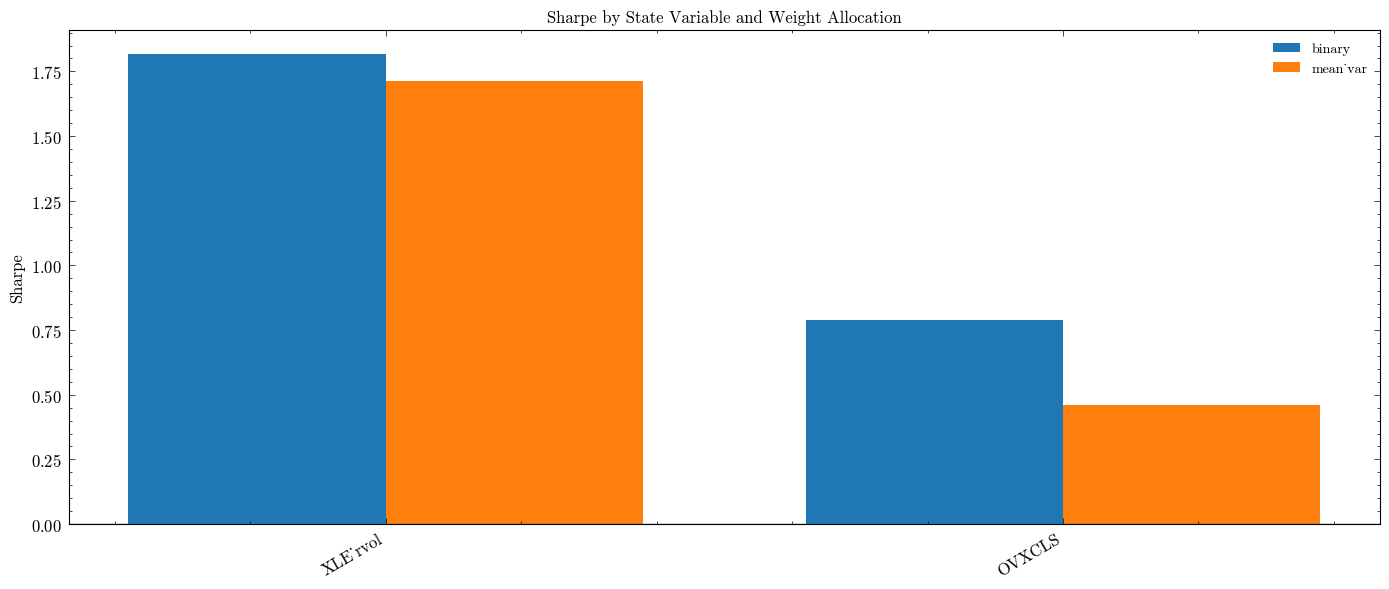

In [14]:
summary = runs_df.copy()  # or: summary = merged.drop_duplicates("run_id").copy()

# keep what we need
summary = summary[["params_state_var", "params_weight_allocation", "metric_gross_sharpe"]].dropna(subset=["params_state_var"])

# ensure numeric sharpe
summary["metric_gross_sharpe"] = pd.to_numeric(summary["metric_gross_sharpe"], errors="coerce")

# average sharpe per (state_var, weight_allocation) in case you have repeats
agg = (
    summary.groupby(["params_state_var", "params_weight_allocation"], as_index=False)["metric_gross_sharpe"]
    .mean()
)

# pivot to wide for plotting
piv = agg.pivot(index="params_state_var", columns="params_weight_allocation", values="metric_gross_sharpe")

# enforce order + ensure both columns exist
for c in ["binary", "mean_var"]:
    if c not in piv.columns:
        piv[c] = np.nan
piv = piv[["binary", "mean_var"]]

# sort by best sharpe (optional)
piv = piv.sort_values(by=["mean_var", "binary"], ascending=False)

# ---------------------------
# Plot grouped bar chart
# ---------------------------
x = np.arange(len(piv.index))
width = 0.38

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(x - width/2, piv["binary"].values, width, label="binary")
ax.bar(x + width/2, piv["mean_var"].values, width, label="mean_var")

ax.set_xticks(x)
ax.set_xticklabels(piv.index, rotation=30, ha="right")
ax.set_ylabel("Sharpe")
ax.set_title("Sharpe by State Variable and Weight Allocation")
ax.axhline(0.0, linewidth=1)  # baseline
ax.legend()
# ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()